In [1]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 82.8 MB/s eta 0:00:00


In [2]:
!git clone https://github.com/ignatiusbalayo/NetLinkArena.git

Cloning into 'NetLinkArena'...
remote: Enumerating objects: 369, done.
remote: Counting objects: 100% (80/80), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 369 (delta 36), reused 43 (delta 18), pack-reused 289 (from 1)
Receiving objects: 100% (369/369), 1.26 MiB | 5.46 MiB/s, done.
Resolving deltas: 100% (162/162), done.


In [3]:
import time
import platform
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.gridspec as gs
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, GATv2Conv, SAGEConv,GINConv
from sklearn.preprocessing import StandardScaler
import networkx as nx
from torch_geometric.utils import to_undirected,remove_self_loops
from sklearn.metrics import roc_auc_score
from torch.optim.lr_scheduler import CosineAnnealingLR
import copy

In [4]:
SEED = 25
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
  torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [6]:
print(f"Pytorch Version  = {torch.__version__}")
print(f"OS  = {platform.system()} {platform.release()}")
print(f"Processor = {platform.processor()}")

Pytorch Version  = 2.10.0+cu128
OS  = Linux 6.6.113+
Processor = x86_64


In [7]:
START_TIME = time.time()
START_TIME

1774239012.5319824

In [8]:
node_feat = pd.read_csv('/content/NetLinkArena/data/public/node_features.csv')
node_feat

,node_id,0,1,2,3,4,5,6,7,8,...,2732,2733,2734,2735,2736,2737,2738,2739,2740,2741
0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0
1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0
2,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0
3,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0
4,4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3322,3322,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
3323,3323,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0
3324,3324,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3325,3325,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0


In [9]:
train_df = pd.read_csv('/content/NetLinkArena/data/public/train_edges.csv')
train_df

,source,target,label
0,920,2242,1
1,2270,3271,1
2,2886,3153,1
3,603,2605,1
4,318,2274,0
...,...,...,...
5455,1496,3267,1
5456,272,797,0
5457,1134,1516,1
5458,2148,2645,0


In [10]:
val_df = pd.read_csv('/content/NetLinkArena/data/public/val_edges.csv')
val_df

,source,target,label
0,428,3249,0
1,720,1999,0
2,305,3236,0
3,1861,3181,0
4,251,2668,1
...,...,...,...
1817,1511,3141,0
1818,298,1911,0
1819,2464,3122,0
1820,149,3107,1


In [11]:
test_df = pd.read_csv('/content/NetLinkArena/data/public/test_nodes.csv')
test_df

,id,source,target
0,0,437,1845
1,1,1802,2608
2,2,941,1249
3,3,1681,2154
4,4,1518,3291
...,...,...,...
1817,1817,298,1664
1818,1818,1053,1824
1819,1819,703,2112
1820,1820,584,3172


#EDA

In [12]:
print(f"Train Edges Shape = {train_df.shape}")
print(f'Val Edges Shape = {val_df.shape}')
print(f'Test Edges Shape = {test_df.shape}')
print(f"Node Features Shape = {node_feat.shape}")

Train Edges Shape = (5460, 3)
Val Edges Shape = (1822, 3)
Test Edges Shape = (1822, 3)
Node Features Shape = (3327, 2743)


In [13]:
num_labels = train_df['label'].unique()
print(f"Num of labels (edge exists vs no edge exists) = {num_labels}")
print(f"Feature columns = {node_feat.columns.to_list()}")
print(f"Train cols = {train_df.columns}")
print(f"Val cols = {val_df.columns}")
print(f"Test cols = {test_df.columns}")

Num of labels (edge exists vs no edge exists) = [1 0]
Feature columns = ['node_id', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', '88', '89', '90', '91', '92', '93', '94', '95', '96', '97', '98', '99', '100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146

In [14]:
tc = train_df['label'].value_counts().sort_index()
tc

,count
label,
0,2730
1,2730


In [15]:
vc = val_df['label'].value_counts().sort_index()
vc

,count
label,
0,911
1,911


In [16]:
num_nodes = len(node_feat['node_id'])
num_features = node_feat.shape[1]-1

In [17]:
node_feat = node_feat.sort_values('node_id').reset_index(drop=True)
X = node_feat.drop(columns=['node_id']).values.astype(np.float32)
X

array([[0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 1., 1., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 1.],
       [0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 1., 0., 1.]], dtype=float32)

In [18]:
train_src = train_df['source'].values
train_dst = train_df['target'].values
train_labels = train_df['label'].values
val_src = val_df['source'].values
val_dst = val_df['target'].values
val_labels = val_df['label'].values
test_ids = test_df['id'].values
test_src = test_df['source'].values
test_dst = test_df['target'].values

In [19]:
test_df

,id,source,target
0,0,437,1845
1,1,1802,2608
2,2,941,1249
3,3,1681,2154
4,4,1518,3291
...,...,...,...
1817,1817,298,1664
1818,1818,1053,1824
1819,1819,703,2112
1820,1820,584,3172


In [20]:
print("Number of nodes",num_nodes)
print("Number of featurs = ",num_features)
print(f"Train edges = {len(train_df)} | pos = {tc[0]} neg = {tc[1]}")
print(f"Val edges = {len(val_df)} | pos = {vc[0]} neg = {vc[1]}")
print(f"Test edges = {len(test_df)} ")
print(f"Feature Sparsity = {(X == 0).mean():.1%}")

Number of nodes 3327
Number of featurs =  2742
Train edges = 5460 | pos = 2730 neg = 2730
Val edges = 1822 | pos = 911 neg = 911
Test edges = 1822 
Feature Sparsity = 96.5%


In [21]:
print(f"Test Edges Id range = {test_df['id'].min()} <-> {test_df['id'].max()}")

Test Edges Id range = 0 <-> 1821


In [22]:
pos_train_mask = train_labels == 1
pos_src = train_src[pos_train_mask]
pos_dst = train_dst[pos_train_mask]

In [23]:
G = nx.Graph()
G.add_nodes_from(range(num_nodes))
G.add_edges_from(zip(pos_src,pos_dst))

In [24]:
degrees = [d for _,d in G.degree()]
comps = sorted(nx.connected_components(G),key=len,reverse=True)
cc_sizes = [len(c) for c in comps]

In [25]:
print(f"Nodes = {G.number_of_nodes()}")
print(f"Edges = {G.number_of_edges()}")
print(f"Is connected = {nx.is_connected(G)}")
print(f"Connected comps = {len(comps)}")
print(f"Largest Comp = {cc_sizes[0]}")
print(f"Mean degree = {np.mean(degrees):.2f}")
print(f'Max degree = {np.max(degrees)} | Min degree = {np.min(degrees)}')
print(f'Nodes with zero Degrees = {sum(1 for d in degrees if d == 0)}')

Nodes = 3327
Edges = 2730
Is connected = False
Connected comps = 1167
Largest Comp = 1288
Mean degree = 1.64
Max degree = 53 | Min degree = 0
Nodes with zero Degrees = 748


/tmp/ipykernel_2959/20570814.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


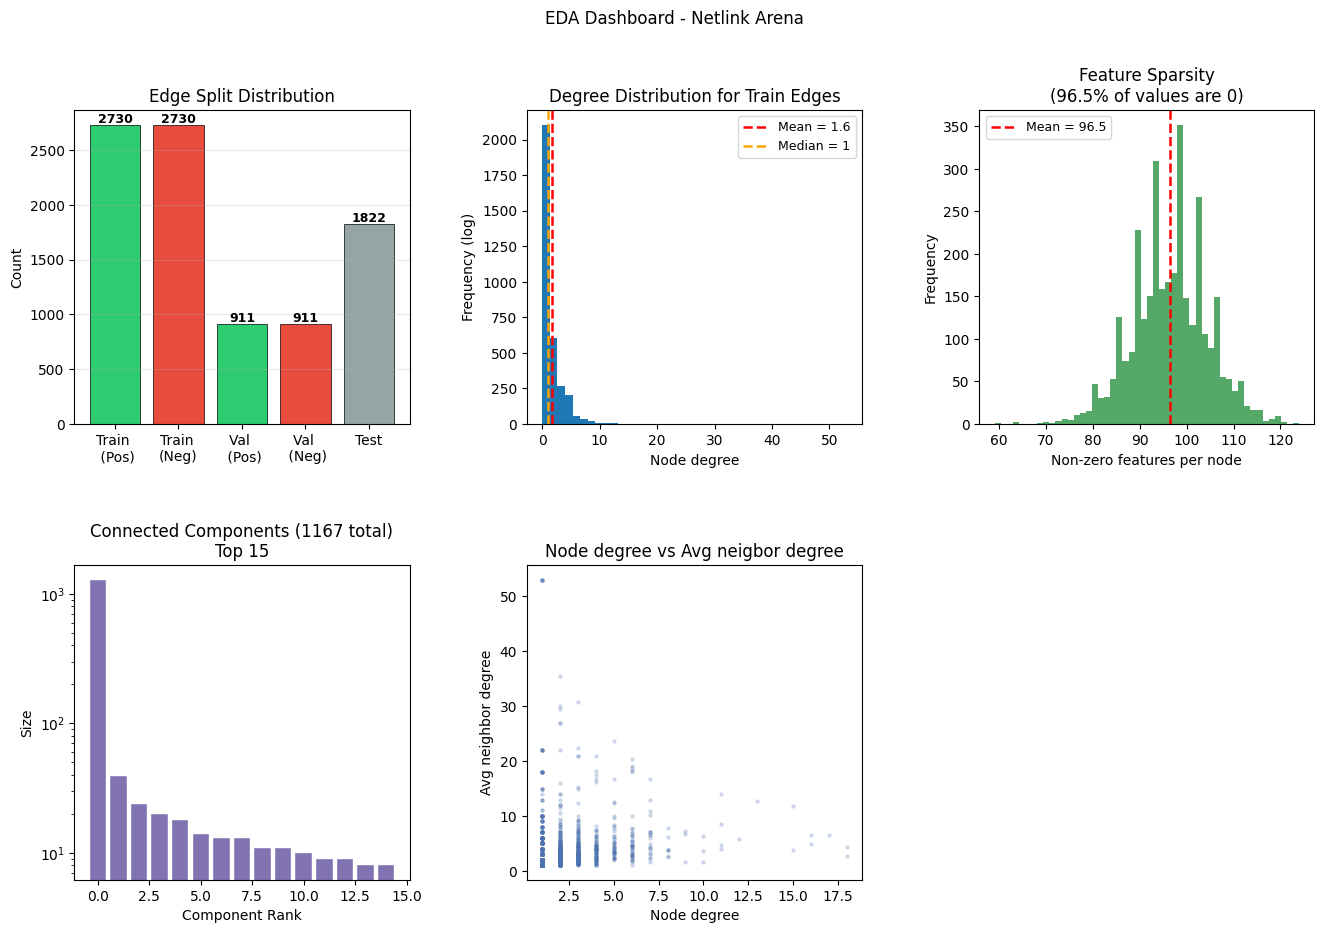

In [26]:
fig = plt.figure(figsize=(16,10))
fig.suptitle("EDA Dashboard - Netlink Arena")
g = gs.GridSpec(2,3,hspace=0.45,wspace=0.35)
ax1 = fig.add_subplot(g[0,0])
splits = ["Train \n (Pos)","Train \n(Neg)","Val \n (Pos)", "Val \n (Neg)","Test"]
counts_plot =  [tc[1], tc[0], vc[1], vc[0], len(test_df)]
colors_plot = ["#2ecc71","#e74c3c","#2ecc71","#e74c3c","#95a5a6"]
bars = ax1.bar(splits, counts_plot, color=colors_plot,
               edgecolor="black", linewidth=0.5)
ax1.set_title("Edge Split Distribution")
ax1.set_ylabel("Count")
for bar, cnt in zip(bars, counts_plot):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 20, str(cnt),
             ha="center", fontsize=9, fontweight="bold")
ax1.grid(axis="y", alpha=0.3)



ax2 = fig.add_subplot(g[0,1])
ax2.hist(degrees,bins=40)
ax2.axvline(np.mean(degrees), color="red", linestyle="--",
            lw=1.8, label=f"Mean = {np.mean(degrees):.1f}")
ax2.axvline(np.median(degrees), color="orange", linestyle="--",
            lw=1.8, label=f"Median = {np.median(degrees):.0f}")
ax2.set_xlabel("Node degree")
ax2.set_ylabel("Frequency (log)")
ax2.set_title("Degree Distribution for Train Edges")
ax2.legend(fontsize=9)



ax3 = fig.add_subplot(g[0,2])
nonzero_per_node = np.count_nonzero(X,axis=1)
ax3.hist(nonzero_per_node,bins=50,color="#55A868")
ax3.axvline(nonzero_per_node.mean(), color="red", linestyle="--",
            lw=1.8, label=f"Mean = {nonzero_per_node.mean():.1f}")
ax3.set_xlabel("Non-zero features per node")
ax3.set_ylabel("Frequency")
ax3.set_title(f"Feature Sparsity\n({(X==0).mean():.1%} of values are 0)")
ax3.legend(fontsize=9)

ax4 = fig.add_subplot(g[1,0])
ax4.bar(range(min(15,len(cc_sizes))),cc_sizes[:15],color='#8172B2',edgecolor="white", linewidth=0.3)
ax4.set_xlabel("Component Rank")
ax4.set_ylabel("Size")
ax4.set_title(f"Connected Components ({len(comps)} total)\nTop 15")
ax4.set_yscale("log")

ax5 = fig.add_subplot(g[1,1])
avg_n_deg = []
node_deg = []
for node in list(G.nodes())[:2000]:
  nbrs = list(G.neighbors(node))
  if nbrs:
    avg_n_deg.append(np.mean([G.degree(n) for n in nbrs]))
    node_deg.append(G.degree(node))
ax5.scatter(node_deg, avg_n_deg, alpha=0.2, s=5, color="#4C72B0")
ax5.set_xlabel("Node degree")
ax5.set_ylabel("Avg neighbor degree")
ax5.set_title("Node degree vs Avg neigbor degree")

plt.tight_layout()
plt.show()




# Graph Construction

In [27]:
zero_feature_nodes = (node_feat.drop(columns=['node_id']).sum(axis=1) == 0).sum()
print(f"Nodes with zero features: {zero_feature_nodes}")

Nodes with zero features: 0


In [28]:
X = torch.tensor(X,dtype=torch.float32)
pos_train_src = train_src[train_labels ==1]
pos_train_dst = train_dst[train_labels == 1]
src_t = torch.LongTensor(pos_train_src)
dst_t = torch.LongTensor(pos_train_dst)

In [29]:
mp_edge_index = torch.stack([src_t, dst_t], dim=0)
mp_edge_index = to_undirected(mp_edge_index, num_nodes=num_nodes)
mp_edge_index, _ = remove_self_loops(mp_edge_index)

In [30]:
print(f"Num of nodes = {num_nodes}")
print(f"Edges: {mp_edge_index.shape[1]:,}")

Num of nodes = 3327
Edges: 5,460


In [31]:
train_edge_tensor  = torch.LongTensor(np.stack([train_src, train_dst]))
train_label_tensor = torch.FloatTensor(train_labels)
val_edge_tensor  = torch.LongTensor(np.stack([val_src, val_dst]))
val_label_tensor = torch.FloatTensor(val_labels)
test_edge_tensor = torch.LongTensor(np.stack([test_src, test_dst]))

In [32]:
data = Data(x=X,edge_index = mp_edge_index,num_nodes=num_nodes)
data

Data(x=[3327, 2742], edge_index=[2, 5460], num_nodes=3327)

In [33]:
print(f"Train Supervision shape = {train_edge_tensor.shape}")
print(f'Val supervision shape = {val_edge_tensor.shape}')
print(f"test preidction shape = {test_edge_tensor.shape}")

Train Supervision shape = torch.Size([2, 5460])
Val supervision shape = torch.Size([2, 1822])
test preidction shape = torch.Size([2, 1822])


In [34]:
def dot_product_decode(z,edge_index):
  src_emb = z[edge_index[0]]
  dst_emb = z[edge_index[1]]
  return (src_emb * dst_emb).sum(dim=-1)
def mlp_decode(z,edge_index,mlp_head):
  src_emb = z[edge_index[0]]
  dst_emb = z[edge_index[1]]
  combined = torch.cat([src_emb,dst_emb],dim=-1)
  return mlp_head(combined).squeeze(-1)

In [61]:
class GCN(nn.Module):
  def __init__(self,in_dim,hidden_dim,out_dim,dropout=0.5):
    super().__init__()
    self.dropout = dropout
    self.gcn1 = GCNConv(in_dim,hidden_dim,cached=True)
    self.bn1 = nn.BatchNorm1d(hidden_dim)
    self.gcn2 = GCNConv(hidden_dim,hidden_dim,cached=True)
    self.bn2=nn.BatchNorm1d(hidden_dim)
    self.gcn3 = GCNConv(hidden_dim,out_dim,cached=True)
  def forward(self,x,edge_index):
    x = F.relu(self.bn1(self.gcn1(x,edge_index)))
    x = F.dropout(x,p=self.dropout,training=self.training)
    x = F.relu(self.bn2(self.gcn2(x,edge_index)))
    x = F.dropout(x,p=self.dropout,training=self.training)
    return self.gcn3(x,edge_index)



In [81]:
class GAT(nn.Module):
  def __init__(self,in_dim,hidden_dim,out_dim,heads,num_of_layers=3,dropout=0.6):
    super().__init__()
    self.dropout = dropout
    self.convs = nn.ModuleList()
    self.bns = nn.ModuleList()
    self.convs.append(GATv2Conv(in_dim,hidden_dim,heads=heads,dropout=dropout,concat=True))
    self.bns.append(nn.BatchNorm1d(hidden_dim * heads))
    for i in range(num_of_layers-2):
      self.convs.append(GATv2Conv(hidden_dim*heads,hidden_dim,heads=heads,dropout=dropout,concat=True))
      self.bns.append(nn.BatchNorm1d(hidden_dim * heads))
    self.convs.append(GATv2Conv(hidden_dim * heads,out_dim,heads=1,dropout=dropout,concat=False))
    self.mlp_decoder = nn.Sequential(
        nn.Linear(out_dim * 2 ,out_dim),
        nn.ReLU(),
        nn.Linear(out_dim,out_dim // 2),
        nn.ReLU(),
        nn.Linear(out_dim//2,1)
    )

  def forward(self,x,edge_index):
    for conv,bn in zip(self.convs[:-1],self.bns):
      x_res = x
      x = conv(x,edge_index)
      x = bn(x)
      x =F.elu(x)
      if x.shape == x_res.shape:
        x = x+x_res
      x=F.dropout(x, p=self.dropout, training=self.training)

    return self.convs[-1](x,edge_index)
  def decode_mlp(self,z,edge_index):
    src = z[edge_index[0]]
    dst = z[edge_index[1]]
    return self.mlp_decoder(torch.cat([src,dst],dim=-1)).squeeze(-1)

In [74]:
class SAGE(nn.Module):
  def __init__(self,in_dim,hidden_dim,out_dim,num_layers=3,dropout=0.5):
    super().__init__()
    self.dropout = dropout
    self.convs = nn.ModuleList()
    self.bns = nn.ModuleList()
    self.convs.append(SAGEConv(in_dim,hidden_dim))
    self.bns.append(nn.BatchNorm1d(hidden_dim))
    for i in range(num_layers-2):
      self.convs.append(SAGEConv(hidden_dim,hidden_dim))
      self.bns.append(nn.BatchNorm1d(hidden_dim))
    self.convs.append(SAGEConv(hidden_dim,out_dim))
    self.mlp_decoder = nn.Sequential(
        nn.Linear(out_dim * 2,out_dim),
        nn.ReLU(),
        nn.Dropout(dropout),
        nn.Linear(out_dim, 1),
    )

  def encode(self, x, edge_index):
    for conv, bn in zip(self.convs[:-1], self.bns):
        x = F.relu(bn(conv(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
    return self.convs[-1](x, edge_index)
  def forward(self,x,edge_index):
    return self.encode(x,edge_index)

  def decode_mlp(self, z, edge_index):
    src = z[edge_index[0]]
    dst = z[edge_index[1]]
    return self.mlp_decoder(torch.cat([src, dst], dim=-1)).squeeze(-1)

In [75]:
class GIN(nn.Module):
  def __init__(self, in_dim, hidden_dim=128, out_dim=64,
                num_layers=3, dropout=0.5):
      super().__init__()
      self.dropout = dropout
      self.convs   = nn.ModuleList()
      self.bns     = nn.ModuleList()
      mlp1 = nn.Sequential(
          nn.Linear(in_dim, hidden_dim), nn.ReLU(),
          nn.Linear(hidden_dim, hidden_dim)
      )
      self.convs.append(GINConv(mlp1, train_eps=True))
      self.bns.append(nn.BatchNorm1d(hidden_dim))

      for i in range(num_layers - 2):
          mlp_mid = nn.Sequential(
              nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
              nn.Linear(hidden_dim, hidden_dim)
          )
          self.convs.append(GINConv(mlp_mid, train_eps=True))
          self.bns.append(nn.BatchNorm1d(hidden_dim))

      mlp_last = nn.Sequential(
          nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
          nn.Linear(hidden_dim, out_dim)
      )
      self.convs.append(GINConv(mlp_last, train_eps=True))

  def forward(self, x, edge_index):
      for conv, bn in zip(self.convs[:-1], self.bns):
          x = F.relu(bn(conv(x, edge_index)))
          x = F.dropout(x, p=self.dropout, training=self.training)
      return self.convs[-1](x, edge_index)

#Training

In [76]:
def compute_loss(encoder,edge_index_mp,x,sup_edge_index,sup_labels,mlp_head=None):
  z = encoder(x,edge_index_mp)
  if mlp_head is not None:
    scores = encoder.decode_mlp(z,sup_edge_index)
  else:
    scores = dot_product_decode(z, sup_edge_index)
  loss = F.binary_cross_entropy_with_logits(scores,sup_labels)
  return loss,z

In [77]:
@torch.no_grad()
def evaluate_auc(encoder,edge_index_mp, x,eval_edge_index,eval_labels,mlp_head=None):
  encoder.eval()
  z = encoder(x,edge_index_mp)
  if mlp_head is not None:
    scores = encoder.decode_mlp(z, eval_edge_index)
  else:
    scores = dot_product_decode(z, eval_edge_index)
  probs = torch.sigmoid(scores).cpu().numpy()
  labels_np = eval_labels.cpu().numpy()
  auc = roc_auc_score(labels_np,probs)
  return auc,probs

In [78]:
def train(encoder,data,train_edge_index,train_labels,val_edge_index,val_labels,epochs=500,lr=0.001, weight_decay=5e-4,patience=80, label="model",use_mlp_decoder=False):
  data = data.to(device)
  encoder = encoder.to(device)
  tr_edge = train_edge_index.to(device)
  tr_lbl = train_labels.to(device)
  val_edge = val_edge_index.to(device)
  val_lbl = val_labels.to(device)
  mp_edge = data.edge_index
  mlp_head = None
  if use_mlp_decoder and hasattr(encoder,'mlp_decoder'):
    mlp_head = encoder

  optimizer = Adam(encoder.parameters(),lr=lr, weight_decay=weight_decay)
  scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
  best_auc = 0.0
  best_state = None
  patience_ctr = 0
  history      = {"loss": [], "val_auc": []}
  t0  = time.time()
  for epoch in range(1,epochs+1):
    encoder.train()
    optimizer.zero_grad()
    loss,z = compute_loss(encoder,mp_edge,data.x,tr_edge,tr_lbl,mlp_head)
    loss.backward()
    optimizer.step()
    scheduler.step()
    history["loss"].append(loss.item())
    val_auc,probs = evaluate_auc(encoder,mp_edge,data.x,val_edge,val_lbl,mlp_head)
    history["val_auc"].append(val_auc)
    if val_auc > best_auc:
      best_auc = val_auc
      best_state = copy.deepcopy(encoder.state_dict())
      patience_ctr = 0
    else:
      patience_ctr += 1
      if patience_ctr > patience:
        print(f'{label} Early stopping at epoch =  {epoch} | best_val_auc = {best_auc:.4f}')
        break

    if epoch % 100 == 0:
      print(f'{label} epoch = {epoch} | loss = {loss.item():.4f} | val auc ={val_auc:.4f} | best auc =  {best_auc:.4f}')
  elapsed = time.time() - t0
  encoder.load_state_dict(best_state)
  encoder.eval()
  return encoder, best_auc, history, elapsed

In [88]:
HP_RESULT = []
in_dim = num_features
hp_run_count = 0
for out_dim in [128]:
  print(f"GCN_{out_dim}")
  hp_run_count += 1
  model_gcn = GCN(in_dim,hidden_dim=128,out_dim=out_dim,dropout=0.5)
  best_gcn_model,best_auc,history,t = train(model_gcn,data,train_edge_tensor,train_label_tensor,val_edge_tensor,val_label_tensor,epochs=300,lr=0.001, patience=40,label=f"GCN_{out_dim}")
  log = {
      "run":hp_run_count,
      "arch":f"GCN",
      'strategy':'manual',
      'out_dim':out_dim,
      'val_auc':round(best_auc,5),
      'time_sec':round(t,1)
  }

  HP_RESULT.append(log)
  print(f"Out Dim= {out_dim} | VAL AUC = {best_auc:.4f} | Time = {t:.0f}")
  print("*"*80)

  print("="*80)
  print("="*80)
  print("="*80)
  print(f"GAT_{out_dim}")
  hp_run_count += 1
  model_gat = GAT(in_dim,128,out_dim,heads=4,num_of_layers=3,dropout=0.6)
  best_gat_model,best_auc,history,t = train(model_gat,data,train_edge_tensor,train_label_tensor,val_edge_tensor,val_label_tensor,epochs=300,lr=0.001, patience=40,label=f"GCN_{out_dim}")
  log = {
      "run":hp_run_count,
      "arch":f"GAT",
      'strategy':'manual',
      'out_dim':out_dim,
      'val_auc':round(best_auc,5),
      'time_sec':round(t,1)
  }
  HP_RESULT.append(log)
  print(f"Out Dim= {out_dim} | VAL AUC = {best_auc:.4f} | Time = {t:.0f}")
  print("*"*80)

  print("="*80)
  print("="*80)
  print("="*80)
  print(f"GIN_{out_dim}")
  hp_run_count += 1
  model_gin = GIN(in_dim,hidden_dim=256,out_dim=out_dim,num_layers=100,dropout=0.5)
  best_gin_model,best_auc,history,t = train(model_gin,data,train_edge_tensor,train_label_tensor,val_edge_tensor,val_label_tensor,epochs=300,lr=0.001, patience=40,label=f"GCN_{out_dim}")
  log = {
      "run":hp_run_count,
      "arch":f"GIN",
      'strategy':'manual',
      'out_dim':out_dim,
      'val_auc':round(best_auc,5),
      'time_sec':round(t,1)
  }
  HP_RESULT.append(log)
  print(f"Out Dim= {out_dim} | VAL AUC = {best_auc:.4f} | Time = {t:.0f}")
  print("*"*80)


  print("="*80)
  print("="*80)
  print("="*80)
  print(f"GraphSAGE_{out_dim}")
  hp_run_count += 1
  model_sage = SAGE(in_dim,hidden_dim=128,out_dim=out_dim,num_layers=4,dropout=0.5)
  best_sage_model,best_auc,history,t = train(model_sage,data,train_edge_tensor,train_label_tensor,val_edge_tensor,val_label_tensor,epochs=300,lr=0.001, patience=40,label=f"GCN_{out_dim}")
  log = {
      "run":hp_run_count,
      "arch":f"GraphSAGE",
      'strategy':'manual',
      'out_dim':out_dim,
      'val_auc':round(best_auc,5),
      'time_sec':round(t,1)
  }
  HP_RESULT.append(log)
  print(f"Out Dim= {out_dim} | VAL AUC = {best_auc:.4f} | Time = {t:.0f}")
  print("*"*80)


GCN_128
GCN_128 Early stopping at epoch =  46 | best_val_auc = 0.7090
Out Dim= 128 | VAL AUC = 0.7090 | Time = 0
********************************************************************************
GAT_128
GCN_128 Early stopping at epoch =  97 | best_val_auc = 0.8105
Out Dim= 128 | VAL AUC = 0.8105 | Time = 4
********************************************************************************
GIN_128
GCN_128 Early stopping at epoch =  70 | best_val_auc = 0.6706
Out Dim= 128 | VAL AUC = 0.6706 | Time = 19
********************************************************************************
GraphSAGE_128
GCN_128 Early stopping at epoch =  83 | best_val_auc = 0.7020
Out Dim= 128 | VAL AUC = 0.7020 | Time = 1
********************************************************************************


In [83]:
HP_RESULT_df = pd.DataFrame(HP_RESULT)
HP_RESULT_df['val_auc'] = HP_RESULT_df['val_auc'].astype(float)
HP_RESULT_df

,run,arch,strategy,out_dim,val_auc,time_sec
0,1,GCN,manual,128,0.69524,1.7
1,2,GAT,manual,128,0.81870,9.9
2,3,GIN,manual,128,0.66977,19.2
3,4,GraphSAGE,manual,128,0.69474,1.4


/tmp/ipykernel_2959/1206835267.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


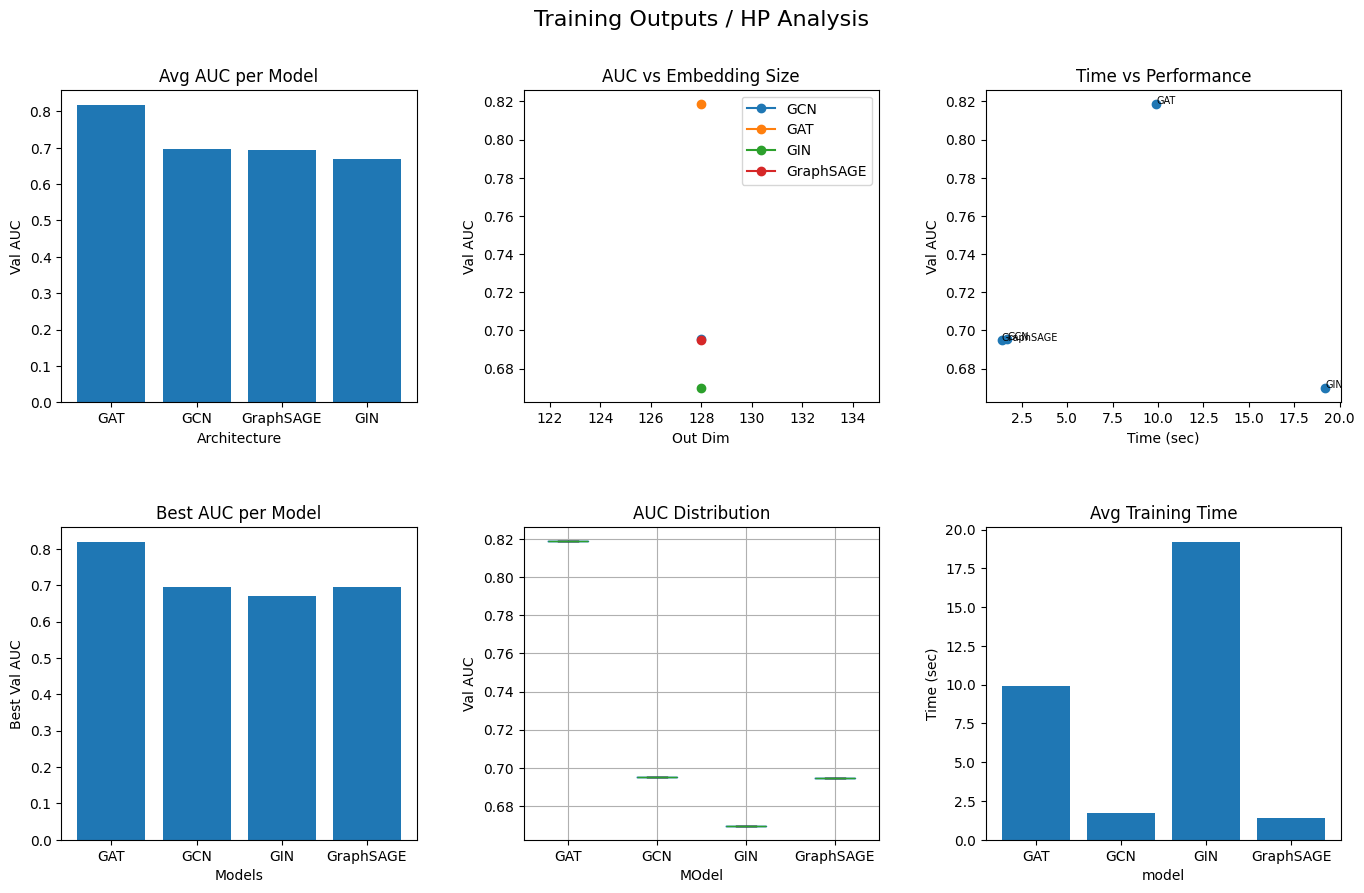

In [84]:
fig = plt.figure(figsize=(16,10))
fig.suptitle("Training Outputs / HP Analysis", fontsize=16)

g = gs.GridSpec(2,3, hspace=0.4, wspace=0.3)

ax1 = fig.add_subplot(g[0,0])
avg_auc = HP_RESULT_df.groupby('arch')['val_auc'].mean().sort_values(ascending=False)
ax1.bar(avg_auc.index, avg_auc.values)
ax1.set_title("Avg AUC per Model")
ax1.set_xlabel("Architecture")
ax1.set_ylabel("Val AUC")

ax2 = fig.add_subplot(g[0,1])
for arch in HP_RESULT_df['arch'].unique():
    subset = HP_RESULT_df[HP_RESULT_df['arch'] == arch]
    ax2.plot(subset['out_dim'], subset['val_auc'], marker='o', label=arch)

ax2.set_title("AUC vs Embedding Size")
ax2.set_xlabel("Out Dim")
ax2.set_ylabel("Val AUC")
ax2.legend()


ax3 = fig.add_subplot(g[0,2])
ax3.scatter(HP_RESULT_df['time_sec'], HP_RESULT_df['val_auc'])

for i, row in HP_RESULT_df.iterrows():
    ax3.text(row['time_sec'], row['val_auc'], row['arch'], fontsize=7)

ax3.set_title("Time vs Performance")
ax3.set_xlabel("Time (sec)")
ax3.set_ylabel("Val AUC")


ax4 = fig.add_subplot(g[1,0])
best_df = HP_RESULT_df.loc[HP_RESULT_df.groupby('arch')['val_auc'].idxmax()]
ax4.bar(best_df['arch'], best_df['val_auc'])
ax4.set_title("Best AUC per Model")
ax4.set_xlabel("Models")
ax4.set_ylabel("Best Val AUC")

ax5 = fig.add_subplot(g[1,1])
HP_RESULT_df.boxplot(column='val_auc', by='arch', ax=ax5)
ax5.set_title("AUC Distribution")
ax5.set_xlabel("MOdel")
ax5.set_ylabel("Val AUC")


fig.suptitle("Training Outputs / HP Analysis", fontsize=16)

ax6 = fig.add_subplot(g[1,2])
avg_time = HP_RESULT_df.groupby('arch')['time_sec'].mean()
ax6.bar(avg_time.index, avg_time.values)
ax6.set_title("Avg Training Time")
ax6.set_xlabel("model")
ax6.set_ylabel("Time (sec)")

plt.tight_layout()
plt.show()

In [89]:
best_gat_model

GAT(
  (convs): ModuleList(
    (0): GATv2Conv(2742, 128, heads=4)
    (1): GATv2Conv(512, 128, heads=4)
    (2): GATv2Conv(512, 128, heads=1)
  )
  (bns): ModuleList(
    (0-1): 2 x BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (mlp_decoder): Sequential(
    (0): Linear(in_features=256, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [94]:
best_gat_model.eval()

val_auc, _ = evaluate_auc(
    best_gat_model,
    data.edge_index,
    data.x,
    val_edge_tensor,
    val_label_tensor,
)
print("Final Validation AUC:", val_auc)

Final Validation AUC: 0.8105150972200968


In [95]:
best_gcn_model.eval()

val_auc, _ = evaluate_auc(
    best_gcn_model,
    data.edge_index,
    data.x,
    val_edge_tensor,
    val_label_tensor,
)
print("Final Validation AUC:", val_auc)

Final Validation AUC: 0.7090078453250369


In [ ]:
best_sage_model.eval()
val_auc, _ = evaluate_auc(
    best_gcn_model,
    data.edge_index,
    data.x,
    val_edge_tensor,
    val_label_tensor,
)
print("Final Validation AUC:", val_auc)

In [96]:
best_gat_model, best_auc, history, t = train(
    model_gat,
    data,
    train_edge_tensor,
    train_label_tensor,
    val_edge_tensor,
    val_label_tensor,
    use_mlp_decoder=False
)

model epoch = 100 | loss = 10.1784 | val auc =0.8159 | best auc =  0.8180
model epoch = 200 | loss = 6.4755 | val auc =0.8273 | best auc =  0.8288
model epoch = 300 | loss = 4.3939 | val auc =0.8309 | best auc =  0.8350
model epoch = 400 | loss = 4.8830 | val auc =0.8358 | best auc =  0.8363
model Early stopping at epoch =  471 | best_val_auc = 0.8363


In [98]:
val_auc, _ = evaluate_auc(
    best_gat_model,
    data.edge_index,
    data.x,
    val_edge_tensor,
    val_label_tensor,
)
print(f"Val AUC = {val_auc}")

Val AUC = 0.836271163158903


In [99]:
@torch.no_grad()
def predict_test(model, data, test_edge_index):
    model.eval()

    data = data.to(device)
    test_edge_index = test_edge_index.to(device)

    z = model(data.x, data.edge_index)

    scores = dot_product_decode(z, test_edge_index)
    probs = torch.sigmoid(scores).cpu().numpy()

    return probs

In [100]:
test_preds = predict_test(best_gat_model, data, test_edge_tensor)

submission = pd.DataFrame({
    "id": test_ids,
    "y_pred": test_preds
})

submission.to_csv("submission.csv", index=False)

In [102]:
submission.shape

(1822, 2)

In [106]:
model_save_path = "best_gat_model.pt"
torch.save(best_gat_model.state_dict(), model_save_path)

In [105]:
END_TIME = time.time() - START_TIME
minutes = END_TIME / 60
print(f"Elapsed time: {minutes:.2f} minutes")

Elapsed time: 101.94 minutes
